# **Portfolio Optimization — Markowitz vs. HRP**
### Out-of-sample comparison on a random 20-stock, $100,000 portfolio

Two classic ways to turn a set of assets into portfolio weights:

| | **Markowitz (mean-variance)** | **HRP (Hierarchical Risk Parity)** |
|---|---|---|
| Idea | Maximize return per unit of risk on the efficient frontier | Allocate risk recursively across a correlation-based asset tree |
| Needs | Expected returns **and** an invertible covariance matrix | Only a correlation/covariance structure — no matrix inversion |
| Known weakness | Very sensitive to estimation error in expected returns | Ignores expected returns entirely — no explicit return-seeking |

Both are implemented — not hand-built — via [`PyPortfolioOpt`](https://pyportfolioopt.readthedocs.io/). The whole workflow: build a random portfolio → split chronologically → optimize on train → backtest on test → compare with the most common performance metrics (via `quantstats`).

**Data:** 5 years of daily closes for a random 20-stock draw from a curated pool of 49 liquid, large-cap S&P 500 names. This execution environment has no outbound route to Yahoo Finance, so we use the well-known Kaggle [`S&P 500 stock data`](https://www.kaggle.com/datasets/camnugent/sandp500) dataset (2013-02-08 to 2018-02-07), saved locally as `sp500_large_cap_pool_prices.csv`. With internet access, the exact same code runs unchanged on live data:

```python
import yfinance as yf
prices = yf.download(tickers, period="5y")["Close"]
```

## Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np
import random

# Chronological train/test split
from sklearn.model_selection import TimeSeriesSplit

# Portfolio optimization (Markowitz + HRP)
from pypfopt import expected_returns, risk_models
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt.hierarchical_portfolio import HRPOpt
from pypfopt.discrete_allocation import DiscreteAllocation

# Performance metrics
import quantstats as qs

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
sns.set_palette("viridis")

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

RANDOM_STATE = 42
N_ASSETS = 20
PORTFOLIO_VALUE = 100_000

%matplotlib inline

## 1. Data

We draw 20 tickers at random (fixed seed, for reproducibility) from the 49-stock pool, forward-fill any missing values, and plot the resulting price histories.

In [2]:
pool_prices = pd.read_csv("sp500_large_cap_pool_prices.csv", index_col="Date", parse_dates=True)
print(f"Pool: {pool_prices.shape[1]} tickers x {pool_prices.shape[0]} trading days "
      f"({pool_prices.index.min().date()} to {pool_prices.index.max().date()})")

random.seed(RANDOM_STATE)
tickers = sorted(random.sample(list(pool_prices.columns), N_ASSETS))
print(f"\nRandomly selected {N_ASSETS} tickers:\n{tickers}")

prices = pool_prices[tickers].ffill()
print(f"\nMissing values after forward-fill: {prices.isna().sum().sum()}")

Pool: 49 tickers x 1259 trading days (2013-02-08 to 2018-02-07)

Randomly selected 20 tickers:
['ABBV', 'ABT', 'AXP', 'BA', 'BAC', 'CAT', 'DIS', 'DUK', 'GE', 'GS', 'MMM', 'PG', 'QCOM', 'SLB', 'T', 'TXN', 'UNH', 'UPS', 'V', 'WFC']

Missing values after forward-fill: 0


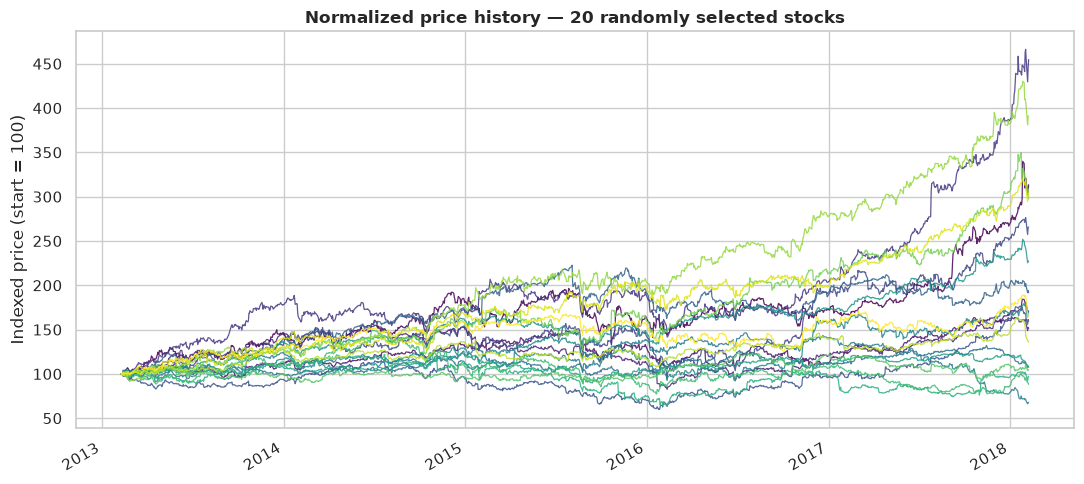

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
(prices / prices.iloc[0] * 100).plot(ax=ax, legend=False, linewidth=0.9, alpha=0.85, colormap="viridis")
ax.set_title(f"Normalized price history — {N_ASSETS} randomly selected stocks", fontweight="bold")
ax.set_ylabel("Indexed price (start = 100)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 2. Train/Test Split

We split 70/30 **chronologically** with scikit-learn's `TimeSeriesSplit`. It requires `n_splits >= 2`, so we set `n_splits=2` with an explicit `test_size`: with a fixed `test_size`, its *last* fold is exactly train = first 70%, test = last 30% — a single time-respecting split. Unlike a plain `train_test_split`, `TimeSeriesSplit` never shuffles observations, avoiding the look-ahead bias a backtest can't tolerate.

In [4]:
n_obs = len(prices)
test_size = int(n_obs * 0.30)

# TimeSeriesSplit requires n_splits >= 2; with test_size fixed, the LAST
# fold is exactly train=first 70%, test=last 30% (a single 70/30 split).
tscv = TimeSeriesSplit(n_splits=2, test_size=test_size)
train_idx, test_idx = list(tscv.split(prices))[-1]

prices_train, prices_test = prices.iloc[train_idx], prices.iloc[test_idx]

print(f"Train: {len(prices_train):>4} days  "
      f"({prices_train.index.min().date()} -> {prices_train.index.max().date()})")
print(f"Test:  {len(prices_test):>4} days  "
      f"({prices_test.index.min().date()} -> {prices_test.index.max().date()})")

Train:  882 days  (2013-02-08 -> 2016-08-09)
Test:   377 days  (2016-08-10 -> 2018-02-07)


## 3. Portfolio Optimization

Both methods are fit **using the training window only** — the test period stays completely unseen until the backtest.

- **Markowitz (mean-variance)** — `EfficientFrontier` finds the *max Sharpe* (tangency) portfolio from historical mean returns and a Ledoit-Wolf shrunk covariance matrix.
- **HRP** — `HRPOpt` clusters assets by their correlation structure and allocates risk recursively down the resulting tree, without ever inverting the covariance matrix (Markowitz's main source of estimation instability).

In [5]:
mu = expected_returns.mean_historical_return(prices_train)
S = risk_models.CovarianceShrinkage(prices_train).ledoit_wolf()

ef = EfficientFrontier(mu, S)
ef.max_sharpe()
w_markowitz = ef.clean_weights()

train_returns = expected_returns.returns_from_prices(prices_train)
hrp = HRPOpt(train_returns)
hrp.optimize()
w_hrp = hrp.clean_weights()

weights_df = pd.DataFrame({"Markowitz": w_markowitz, "HRP": w_hrp}).fillna(0.0)
weights_df = weights_df.loc[(weights_df != 0).any(axis=1)].sort_values("Markowitz", ascending=False)
weights_df.style.format("{:.1%}").background_gradient(cmap="Blues", axis=0)

,Markowitz,HRP
UNH,47.3%,4.8%
MMM,19.3%,4.5%
V,15.4%,2.4%
TXN,13.9%,3.6%
DIS,2.9%,4.0%
ABBV,1.1%,3.8%
ABT,0.0%,4.5%
AXP,0.0%,4.2%
BA,0.0%,4.9%
DUK,0.0%,11.4%


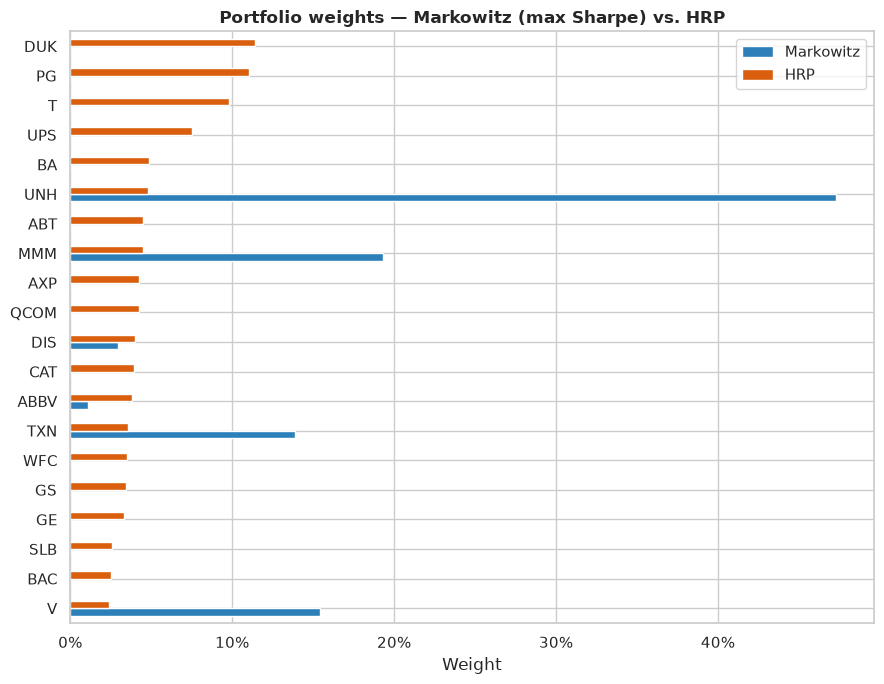

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
weights_df.sort_values("HRP").plot(kind="barh", ax=ax, color=["#2c7fb8", "#d95f0e"])
ax.set_title("Portfolio weights — Markowitz (max Sharpe) vs. HRP", fontweight="bold")
ax.set_xlabel("Weight")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.show()

### Turning weights into a real $100,000 portfolio

`DiscreteAllocation` converts each method's continuous weights into whole shares, deployed at the prices on the **first day of the test period** — the moment we'd actually put train-derived weights into practice.

In [7]:
latest_prices = prices_test.iloc[0]

for name, w in [("Markowitz", w_markowitz), ("HRP", w_hrp)]:
    da = DiscreteAllocation(w, latest_prices, total_portfolio_value=PORTFOLIO_VALUE)
    alloc, leftover = da.greedy_portfolio()
    print(f"{name}: {len(alloc)} positions, ${leftover:,.2f} leftover cash")
    print(f"  {alloc}\n")

Markowitz: 6 positions, $49.22 leftover cash
  {'UNH': 332, 'MMM': 108, 'V': 194, 'TXN': 199, 'DIS': 30, 'ABBV': 17}

HRP: 20 positions, $1.47 leftover cash
  {'DUK': 136, 'PG': 128, 'T': 227, 'UPS': 68, 'BA': 37, 'UNH': 34, 'ABT': 100, 'MMM': 25, 'AXP': 65, 'QCOM': 68, 'DIS': 41, 'CAT': 47, 'ABBV': 58, 'TXN': 51, 'WFC': 72, 'GS': 22, 'GE': 107, 'SLB': 32, 'BAC': 170, 'V': 30}



## 4. Out-of-Sample Backtest

We apply the **train-derived, fixed** weights to the **test-period** daily returns (buy-and-hold, no rebalancing) and track how a real $100,000 invested on day one of the test window would have evolved.

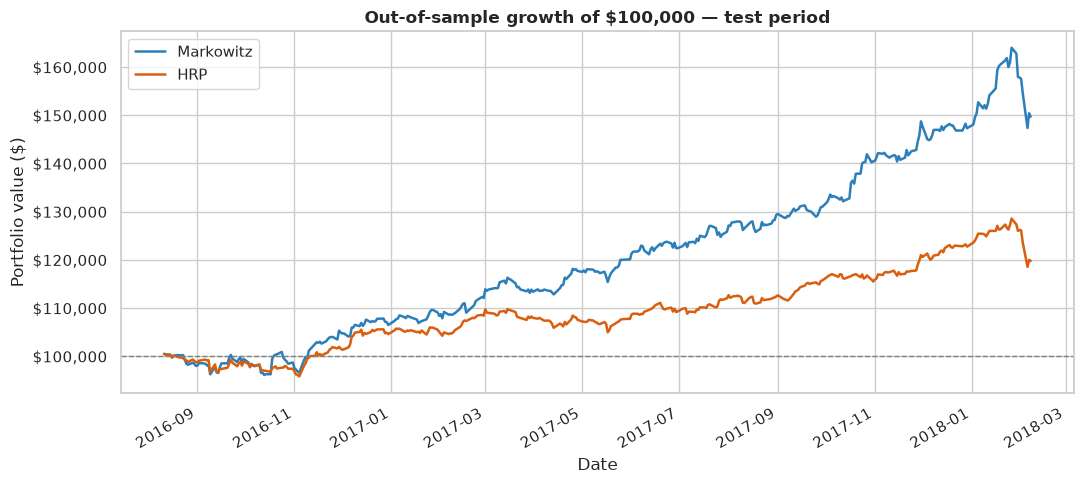

In [8]:
test_returns = prices_test.pct_change().dropna()

port_returns = pd.DataFrame({
    "Markowitz": test_returns[list(w_markowitz)].mul(pd.Series(w_markowitz)).sum(axis=1),
    "HRP": test_returns[list(w_hrp)].mul(pd.Series(w_hrp)).sum(axis=1),
})

equity = PORTFOLIO_VALUE * (1 + port_returns).cumprod()

fig, ax = plt.subplots(figsize=(11, 5))
equity.plot(ax=ax, color=["#2c7fb8", "#d95f0e"], linewidth=1.8)
ax.axhline(PORTFOLIO_VALUE, color="grey", ls="--", lw=1)
ax.set_title("Out-of-sample growth of $100,000 — test period", fontweight="bold")
ax.set_ylabel("Portfolio value ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## 5. Results

We compare both strategies on the held-out test period with the five performance metrics most commonly used to evaluate a portfolio today, computed with `quantstats` — nothing hand-rolled:

- **CAGR** — annualized compounded return.
- **Volatility** — annualized standard deviation of daily returns.
- **Sharpe Ratio** — return per unit of total risk.
- **Max Drawdown** — worst peak-to-trough loss.
- **Sortino Ratio** — return per unit of *downside* risk only.

In [9]:
metrics = {}
for name, r in port_returns.items():
    metrics[name] = {
        "CAGR": qs.stats.cagr(r),
        "Volatility": qs.stats.volatility(r),
        "Sharpe": qs.stats.sharpe(r),
        "Max Drawdown": qs.stats.max_drawdown(r),
        "Sortino": qs.stats.sortino(r),
    }

results_df = pd.DataFrame(metrics).T
results_df.style.format({
    "CAGR": "{:.2%}", "Volatility": "{:.2%}", "Sharpe": "{:.2f}",
    "Max Drawdown": "{:.2%}", "Sortino": "{:.2f}",
}).background_gradient(cmap="Greens", subset=["CAGR", "Sharpe", "Sortino"]) \
  .background_gradient(cmap="Reds_r", subset=["Volatility", "Max Drawdown"])

,CAGR,Volatility,Sharpe,Max Drawdown,Sortino
Markowitz,31.05%,11.82%,2.35,-10.14%,3.63
HRP,12.84%,8.73%,1.43,-7.79%,1.97


## Conclusions

- **Markowitz concentrated hard**: of 20 candidate assets, the max-Sharpe optimizer put non-zero weight on only 6 — a well-known symptom of mean-variance optimization being highly sensitive to estimation error in expected returns (a handful of names with the best historical Sharpe dominate the solution).
- **HRP stayed diversified**: it kept an economically meaningful position in all 20 assets, since it allocates risk through the correlation-cluster tree rather than chasing estimated expected returns.
- **Out-of-sample, on this particular random draw, Markowitz won on raw return** (CAGR 31.1% vs. 12.8%, Sharpe 2.35 vs. 1.43, Sortino 3.63 vs. 1.97) **but also carried more risk** (volatility 11.8% vs. 8.7%, max drawdown -10.1% vs. -7.8%).
- This is the textbook trade-off, not a general verdict: Markowitz's concentrated bet paid off in this specific test window, but that same concentration is exactly what makes it fragile out-of-sample when the estimated expected returns turn out to be wrong — which is the standard critique motivating HRP in the first place. A fairer comparison would repeat this whole pipeline (random draw -> split -> optimize -> backtest) across many random seeds and compare the *distribution* of outcomes, not a single run.
- **Practical takeaway**: HRP is the more robust default when expected returns are hard to estimate reliably (most of the time); Markowitz can outperform when its return estimates happen to be directionally right, at the cost of concentration risk.